<a href="https://colab.research.google.com/github/kavehkarimadini/ARC_101_Pre_Processing/blob/master/Encoding_Normalization_Chi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Label Encoding and Its Characteristics**

**Label Encoding** converts categorical data into numeric values by assigning an integer to each unique category. It is part of the preprocessing steps for machine learning models that require numerical inputs.

#### How Label Encoding Works
For a column with categories:
```
['High', 'Medium', 'Low']
```
Label encoding assigns:
```
High -> 0
Medium -> 1
Low -> 2
```

#### Limitations for Nominal Data
Label encoding is **not suitable for nominal data** because it introduces a **false ordinal relationship** between categories. For example, if the categories are `['Red', 'Green', 'Blue']`, the encoded values:
```
Red -> 0
Green -> 1
Blue -> 2
```
imply:
- Green is "greater than" Red.
- Blue is "greater than" Green.

These relationships are meaningless for nominal data because there is no inherent order among the categories.

### **Why One-Hot Encoding Is Better for Nominal Data**

**One-hot encoding** represents each category as a separate binary column, avoiding the ordinal assumption. For example:
- Input categories: `['Red', 'Green', 'Blue']`
- Output columns:
```
Red   Green   Blue
1      0       0
0      1       0
0      0       1
```

One-hot encoding ensures:
1. **No Ordinal Bias**: Categories are treated as independent and unrelated.
2. **Suitability for Distance-Based Algorithms**: Many machine learning algorithms (e.g., k-NN, SVM) rely on distances, and one-hot encoding prevents misleading distances caused by ordinal encoding.

### **Dropping a Column in One-Hot Encoding**
When using one-hot encoding, you often create \(n\) columns for \(n\) unique categories. However, one of these columns can be dropped without losing information due to the **dummy variable trap**.

#### **What is the Dummy Variable Trap?**
- When all \(n\) one-hot columns are used, the data has a **linear dependency**: the value of one column can be deduced from the others.
  - Example: For \(Red = 0, Green = 1, Blue = 0\), you can infer the category is `Green` without explicitly having a `Green` column.
- This redundancy can introduce multicollinearity, which might confuse some machine learning models.

#### **How Dropping a Column Helps**
1. **Removes Redundancy**: Dropping one column ensures that the remaining columns still capture all the information about the categories.
2. **Improves Model Efficiency**: Reduces dimensionality without losing predictive power.
3. **Prevents Multicollinearity**: Helps models that assume independence between features (e.g., linear regression).

#### Example of Dropping a Column
For \(n = 3\) categories (`Red`, `Green`, `Blue`), the one-hot encoding would look like this:

| Red | Green | Blue |
|-----|-------|------|
| 1   | 0     | 0    |
| 0   | 1     | 0    |
| 0   | 0     | 1    |

If we drop the `Blue` column:

| Red | Green |
|-----|-------|
| 1   | 0     |
| 0   | 1     |
| 0   | 0     |

You can still deduce the `Blue` category when both `Red` and `Green` are `0`.

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Sample dataset
data = {
    'Age': [25, 32, 47, 19],
    'Education': ['High School', 'Bachelor', 'Master', 'High School'],  # Ordinal
    'City': ['New York', 'Los Angeles', 'New York', 'Chicago'],  # Nominal
    'Salary': [50000, 60000, 75000, 45000]
}

# Convert to DataFrame
df = pd.DataFrame(data)

In [11]:
df

,Age,Education,City,Salary
0,25,High School,New York,50000
1,32,Bachelor,Los Angeles,60000
2,47,Master,New York,75000
3,19,High School,Chicago,45000


In [12]:
# Define ordinal and nominal columns
ordinal_columns = ['Education']
nominal_columns = ['City']

In [13]:
# Step 1: Encode ordinal columns using LabelEncoder
ordinal_encoder = LabelEncoder()
for col in ordinal_columns:
    df[col] = ordinal_encoder.fit_transform(df[col])

In [14]:
df

,Age,Education,City,Salary
0,25,1,New York,50000
1,32,0,Los Angeles,60000
2,47,2,New York,75000
3,19,1,Chicago,45000


In [23]:
# Step 2: Encode nominal columns using get_dummies
df_encoded = pd.get_dummies(df, columns=nominal_columns,drop_first=True)

# Display the transformed DataFrame
df_encoded

,Age,Education,Salary,City_Los Angeles,City_New York
0,25,1,50000,False,True
1,32,0,60000,True,False
2,47,2,75000,False,True
3,19,1,45000,False,False


In [26]:
# Iterate through the boolean columns and map True/False to 1/0
for col in df_encoded.select_dtypes(include='bool'):
    df_encoded[col] = df_encoded[col].map({False: 0, True: 1})

In [27]:
df_encoded

,Age,Education,Salary,City_Los Angeles,City_New York
0,25,1,50000,0,1
1,32,0,60000,1,0
2,47,2,75000,0,1
3,19,1,45000,0,0


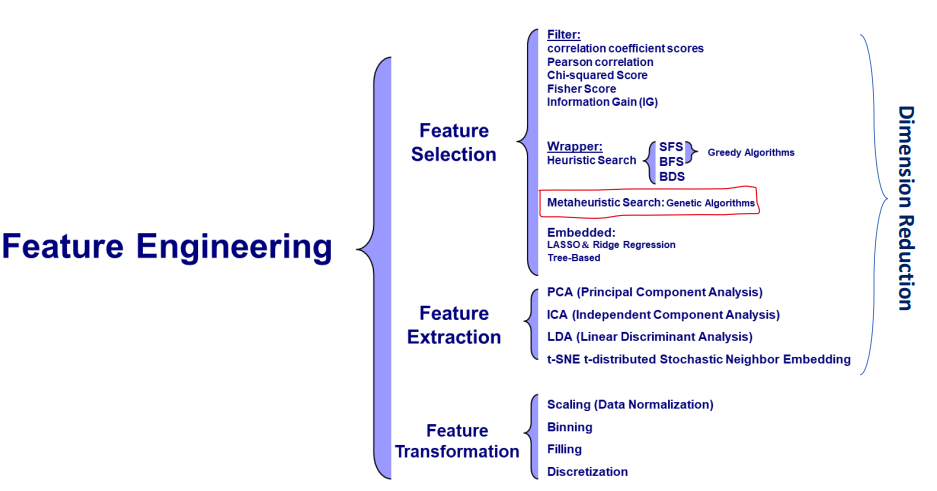

In [28]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2

# Load the dataset
data = load_iris()

# Convert to a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [30]:
# Display the dataset structure
print("Dataset structure:")
df.head()

Dataset structure:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# $chi^2$
Discretizing the independent variables is necessary when using the Chi-Squared $chi^2$ test because the test is designed to evaluate the **relationship between categorical variables**. Here's why:

---

### **1. Chi-Squared Test Assumptions**
The Chi-Squared test operates on a **contingency table**, which summarizes the counts (or frequencies) of occurrences of combinations of categories between two variables. For example:
- One variable could represent feature values (e.g., age groups: `0-10`, `11-20`, etc.).
- The other variable could represent target classes (e.g., `spam` or `not spam`).

If the independent variables are continuous, they cannot be directly used to form contingency tables because they lack discrete categories.

---

### **2. Problem with Continuous Variables**
Continuous variables have an infinite range of values (e.g., `3.14159`, `7.52`, etc.), so:
- It is impossible to calculate frequencies for all possible values.
- A contingency table cannot be created without grouping the values into categories.

Example:
- Feature: `Height` (continuous)
- Target: `Gender` (categorical: `Male`, `Female`)

To compute the Chi-Squared statistic, we might discretize `Height` into bins:
- `Short`, `Medium`, `Tall`

---

### **3. Solution: Discretization**
Discretization (or binning) groups continuous data into intervals or categories, allowing the formation of a contingency table for the Chi-Squared test.

For example:
- Feature: `Age` (continuous: `[21.5, 30.1, 45.7]`)
- After discretization: `[20-30, 30-40, 40-50]`

Contingency table:

| Age Group  | Target: Yes | Target: No |
|------------|-------------|------------|
| 20-30      | 10          | 15         |
| 30-40      | 20          | 10         |
| 40-50      | 5           | 25         |

From this table, the Chi-Squared test can measure how strongly `Age Group` and `Target` are associated.

---

### **4. Practical Considerations**
1. **Choice of Binning Strategy**:
   - Use equal-width bins (`pd.cut`) or quantile-based bins (`pd.qcut`).
   - Ensure the bins are meaningful and capture the variable's distribution.

2. **Trade-Off**:
   - Too many bins can dilute the frequencies, leading to sparse contingency tables and unreliable Chi-Squared statistics.
   - Too few bins can oversimplify the data, losing important nuances.

3. **Model Context**:
   - If the original continuous features are important for your model, consider using methods other than Chi-Squared (e.g., correlation tests for linear relationships).

---

### **5. Key Points**
- **Why discretize?** To transform continuous variables into categorical ones, enabling the Chi-Squared test to measure their association with the target.
- **When to discretize?** When applying the Chi-Squared test on continuous features for feature selection.
- **Alternatives?** If the features should remain continuous, consider other statistical methods like ANOVA (for categorical targets) or correlation (for continuous targets).

---

In [31]:
# Chi-Squared Test
# For the test, ensure the features and target are discrete (use discretization if needed).
# Discretize the continuous features
for col in data.feature_names:
    df[col] = pd.cut(df[col], bins=4, labels=[0, 1, 2, 3])  # Discretize into 4 bins

In [32]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,0,2,0,0,0
1,0,1,0,0,0
2,0,1,0,0,0
3,0,1,0,0,0
4,0,2,0,0,0
...,...,...,...,...,...
145,2,1,2,3,2
146,2,0,2,2,2
147,2,1,2,3,2
148,2,2,2,3,2


In [33]:
# Define features (X) and target (y)
X = df[data.feature_names]
y = df['target']

# Apply Chi-Squared test
chi2_selector = SelectKBest(chi2, k=2)  # Select top 2 features
X_kbest = chi2_selector.fit_transform(X, y)

In [34]:
# Display the selected features
selected_features = [data.feature_names[i] for i in chi2_selector.get_support(indices=True)]
print(f"Selected Features: {selected_features}")

Selected Features: ['petal length (cm)', 'petal width (cm)']


In [39]:
chi2_selector.scores_, chi2_selector.pvalues_

(array([ 69.43023256,  24.56      , 119.01382488, 124.74626866]),
 array([8.38332999e-16, 4.64369580e-06, 1.43375944e-26, 8.16003351e-28]))

In [40]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

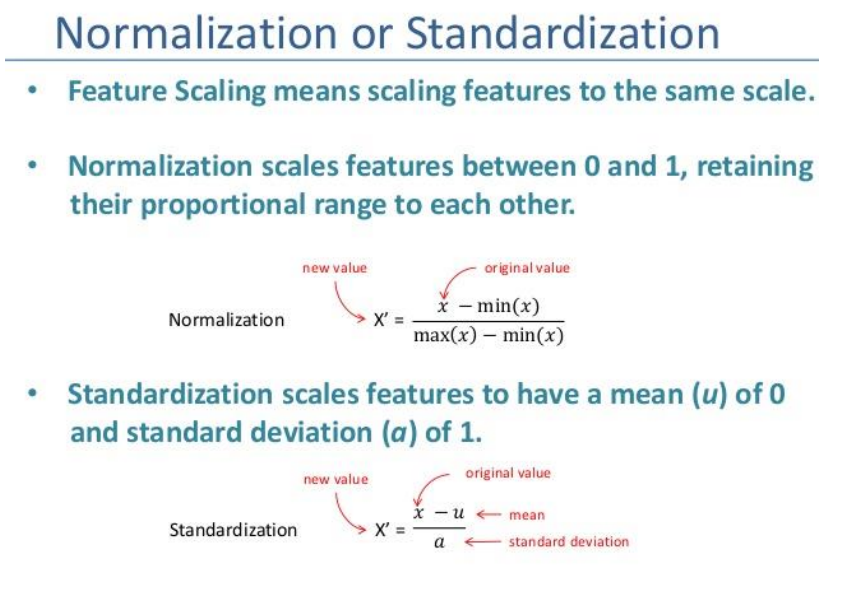

### **Introduction to Standardization and Min-Max Scaling**

Feature scaling is a preprocessing step used in machine learning to normalize the range or distribution of features so that they contribute equally to the model. Two common techniques are **Standardization** and **Min-Max Scaling**.

---

### **1. Standardization**

- **Definition**: Transforms data to have a mean of **0** and a standard deviation of **1**.
- **Formula**:
 $
  Z = \frac{X - \mu}{\sigma}
  $
  Where:
  - \( X \) = Original value
  - $ \mu $ = Mean of the feature
  - $\sigma$ = Standard deviation of the feature

- **Use Case**:
  - Ideal for datasets where features have a Gaussian (normal) distribution.
  - Used in algorithms sensitive to the scale of features, such as:
    - Support Vector Machines (SVMs)
    - Logistic Regression
    - Principal Component Analysis (PCA)

- **Effect**:
  - Scales data to fit within a standard normal distribution, making it easier for the model to converge during optimization.

---

### **2. Min-Max Scaling**

- **Definition**: Scales features to a fixed range, typically \([0, 1]\).
- **Formula**:
  $
  X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
  $
  Where:
  - \( X \) = Original value
  - $ X_{\text{min}} $= Minimum value of the feature
  - $ X_{\text{max}} $ = Maximum value of the feature

- **Use Case**:
  - Suitable for datasets with non-Gaussian (e.g., uniform, skewed) distributions.
  - Common in algorithms like:
    - Neural Networks (to ensure activations are in a bounded range)
    - K-Nearest Neighbors (distance-based algorithms)

- **Effect**:
  - Preserves the relative scale of the data while mapping it to a fixed range.
  - Sensitive to outliers, as they can significantly stretch the range.

---

### **Key Differences**

| **Aspect**           | **Standardization**                | **Min-Max Scaling**              |
|-----------------------|------------------------------------|-----------------------------------|
| **Output Range**      | Mean = 0, Standard Deviation = 1   | Fixed range (e.g., [0, 1])       |
| **Handles Outliers**  | Less sensitive                    | Highly sensitive                 |
| **Use Case**          | Gaussian-distributed data         | Non-Gaussian-distributed data    |
| **Algorithms**        | SVM, PCA, Logistic Regression     | Neural Networks, KNN             |

---

### **Example**

**Original Data**: [10, 20, 30, 40, 50]

- **Standardization**:
  - Transformed Data: [-1.41, -0.71, 0, 0.71, 1.41]
- **Min-Max Scaling** (range [0, 1]):
  - Transformed Data: [0, 0.25, 0.5, 0.75, 1]

---

Both techniques are vital for ensuring consistent feature ranges, improving model accuracy and training speed. The choice depends on the dataset and the algorithm you're using.

In [42]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import shapiro

In [43]:
# Load dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Display first few rows
print("Dataset Head:")
print(df.head())

Dataset Head:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [44]:
# Function to check normality using Shapiro-Wilk test
def check_normality(series):
    stat, p_value = shapiro(series)
    return p_value > 0.05  # If p > 0.05, the feature is approximately normal

In [45]:
# Separate normal and non-normal columns
normal_columns = []
non_normal_columns = []

for col in df.columns:
    if check_normality(df[col]):
        normal_columns.append(col)
    else:
        non_normal_columns.append(col)

print("\nNormal Columns:", normal_columns)
print("Non-Normal Columns:", non_normal_columns)


Normal Columns: ['sepal width (cm)']
Non-Normal Columns: ['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']


In [46]:
# Standardize normal columns
scaler_standard = StandardScaler()
df[normal_columns] = scaler_standard.fit_transform(df[normal_columns])

# Apply MinMax scaling to non-normal columns
scaler_minmax = MinMaxScaler()
df[non_normal_columns] = scaler_minmax.fit_transform(df[non_normal_columns])

# Display scaled DataFrame
print("\nScaled Dataset:")
print(df.head())


Scaled Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          1.019004           0.067797          0.041667
1           0.166667         -0.131979           0.067797          0.041667
2           0.111111          0.328414           0.050847          0.041667
3           0.083333          0.098217           0.084746          0.041667
4           0.194444          1.249201           0.067797          0.041667
